In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df= pd.read_csv('../datasets/airline_ticket_prices_dataset.csv')
df.head()

,Ticket_ID,Airline,Origin,Destination,Distance_km,Class,Days_Before_Departure,Price_USD
0,1,Saudia,Mumbai,Paris,2643,Economy,28,555.30
1,2,Etihad,Istanbul,Jeddah,8266,Business,98,2070.27
2,3,British Airways,Dubai,Riyadh,2698,First,21,1883.11
3,4,Emirates,London,Istanbul,7956,First,24,5349.65
4,5,Qatar Airways,Doha,Dubai,1308,Business,60,516.19


In [5]:
df.shape

(250, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              250 non-null    int64  
 1   Airline                250 non-null    object 
 2   Origin                 250 non-null    object 
 3   Destination            250 non-null    object 
 4   Distance_km            250 non-null    int64  
 5   Class                  250 non-null    object 
 6   Days_Before_Departure  250 non-null    int64  
 7   Price_USD              250 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 15.8+ KB


In [7]:
df.describe()

,Ticket_ID,Distance_km,Days_Before_Departure,Price_USD
count,250.000000,250.000000,250.000000,250.000000
mean,125.500000,5999.952000,59.024000,2006.059760
std,72.312977,3401.695261,33.736628,1675.067217
min,1.000000,336.000000,1.000000,106.070000
25%,63.250000,2991.750000,31.250000,818.665000
50%,125.500000,6132.500000,60.500000,1531.235000
75%,187.750000,8832.750000,86.750000,2590.357500
max,250.000000,11903.000000,118.000000,8852.690000


In [9]:
df.isnull().sum()

Ticket_ID                0
Airline                  0
Origin                   0
Destination              0
Distance_km              0
Class                    0
Days_Before_Departure    0
Price_USD                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [14]:
print('average price',df['Price_USD'].mean())
print('max price',df['Price_USD'].max())
print('min price',df['Price_USD'].min())

2006.05976
8852.69
106.07


<Axes: xlabel='Price_USD', ylabel='Count'>

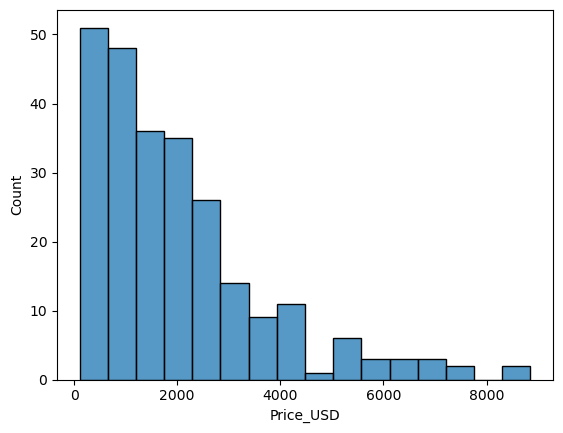

In [15]:
sns.histplot(df['Price_USD'])

In [19]:
df.groupby('Airline')['Price_USD'].mean().sort_values(ascending=False)

Airline
Saudia              2389.397500
Turkish Airlines    2140.443000
Emirates            2103.242813
Qatar Airways       2069.334722
Lufthansa           2066.626176
British Airways     1934.800833
Flynas              1671.064615
Etihad              1486.471250
Name: Price_USD, dtype: float64

<Axes: xlabel='Airline'>

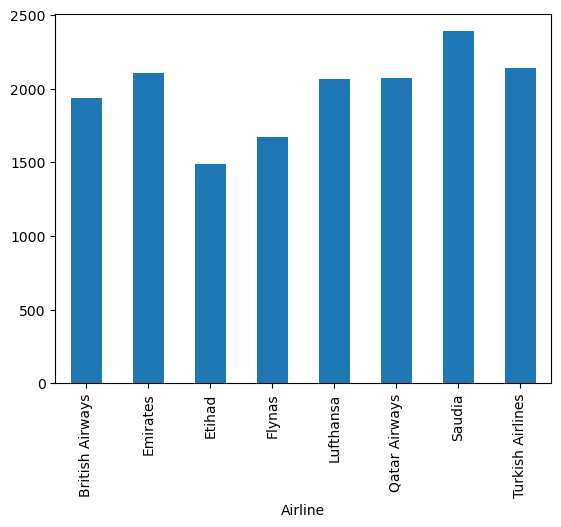

In [20]:
#which flight costs more

df.groupby('Airline')['Price_USD'].mean().plot(kind='bar')

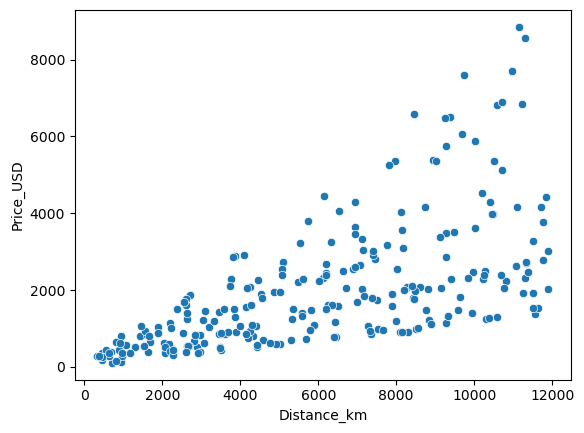

In [22]:

#Do longer flights cost more?
sns.scatterplot(x='Distance_km', y='Price_USD', data=df)
plt.show()

In [23]:
df[['Distance_km','Price_USD']].corr()

,Distance_km,Price_USD
Distance_km,1.000000,0.642546
Price_USD,0.642546,1.000000


In [26]:
df.groupby('Class')['Price_USD'].mean().sort_values(ascending=False)

Class
First       3048.605233
Business    1939.808133
Economy     1054.486292
Name: Price_USD, dtype: float64

<Axes: xlabel='Class'>

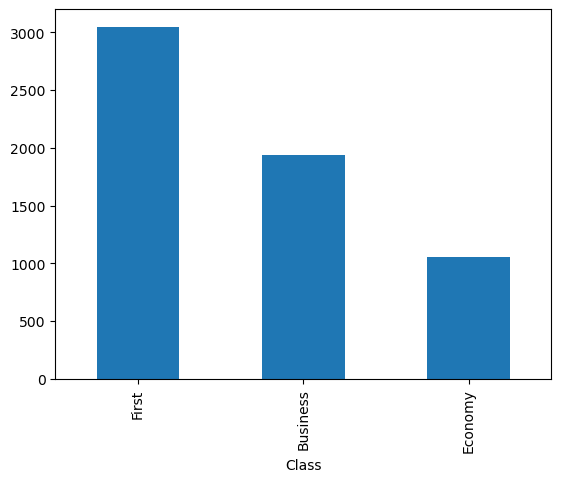

In [29]:
df.groupby('Class')['Price_USD'].mean().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='Class', ylabel='Price_USD'>

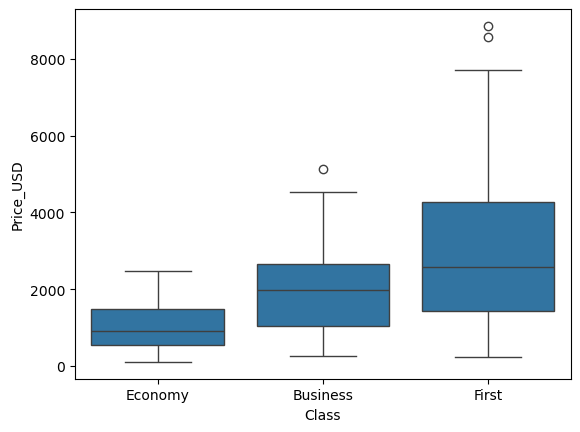

In [30]:
sns.boxplot(x='Class', y='Price_USD', data=df)

<Axes: xlabel='Days_Before_Departure', ylabel='Price_USD'>

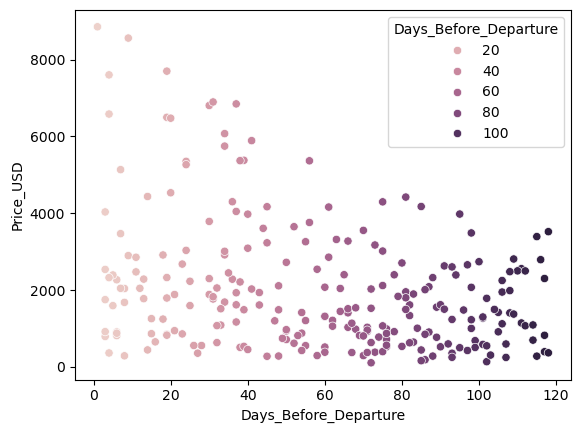

In [33]:
#Do tickets get more expensive closer to departure?
sns.scatterplot(x='Days_Before_Departure', y='Price_USD', data=df,hue='Days_Before_Departure')

In [34]:
df['Route'] = df['Origin'] + "-" + df['Destination']

In [35]:
df.groupby('Route')['Price_USD'].mean().sort_values(ascending=False)

Route
London-Mumbai     5576.315
New York-Doha     5393.520
Paris-Mumbai      5367.820
Doha-Jeddah       5281.280
Riyadh-Doha       5264.140
                    ...   
Dubai-Doha         804.600
Mumbai-Dubai       770.280
New York-Dubai     650.830
Mumbai-Doha        451.040
Istanbul-Paris     273.060
Name: Price_USD, Length: 85, dtype: float64

In [36]:
df['Airline'].value_counts()

Airline
British Airways     36
Qatar Airways       36
Lufthansa           34
Saudia              32
Emirates            32
Turkish Airlines    30
Flynas              26
Etihad              24
Name: count, dtype: int64

<Axes: xlabel='Airline', ylabel='count'>

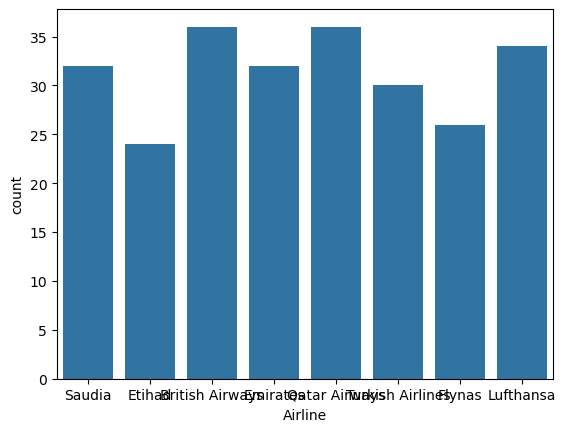

In [37]:
sns.countplot(x='Airline', data=df)

In [38]:
df.groupby(['Airline','Class'])['Price_USD'].mean()

Airline           Class   
British Airways   Business    1927.000000
                  Economy      991.235714
                  First       3042.127500
Emirates          Business    2175.815714
                  Economy     1109.684667
                  First       3542.779000
Etihad            Business    1477.442727
                  Economy     1120.945714
                  First       1929.470000
Flynas            Business    1450.385556
                  Economy      955.005556
                  First       2724.895000
Lufthansa         Business    2092.140000
                  Economy     1079.788462
                  First       3321.450000
Qatar Airways     Business    1546.215455
                  Economy     1063.068000
                  First       3123.800000
Saudia            Business    3019.644286
                  Economy      920.746667
                  First       3405.711538
Turkish Airlines  Business    2280.015556
                  Economy     1240.905556
       

<Axes: xlabel='Airline', ylabel='Price_USD'>

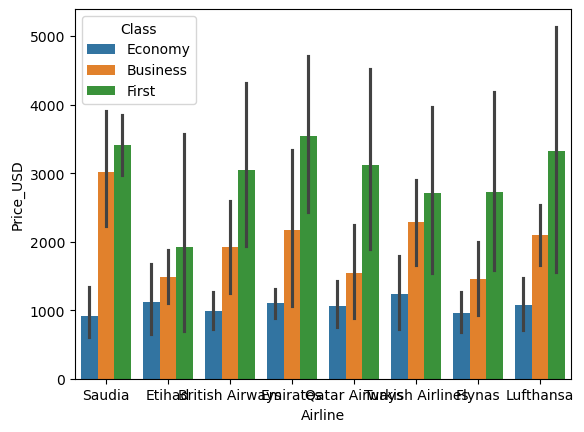

In [39]:
sns.barplot(x='Airline', y='Price_USD', hue='Class', data=df)

In [40]:
df['Distance_Category'] = pd.cut(
    df['Distance_km'],
    bins=[0,1000,3000,7000,15000],
    labels=['Short','Medium','Long','Ultra Long']
)

<Axes: xlabel='Price_USD'>

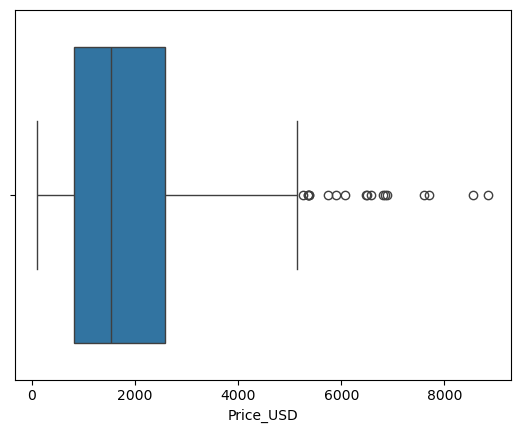

In [41]:
sns.boxplot(x=df['Price_USD'])

<Axes: >

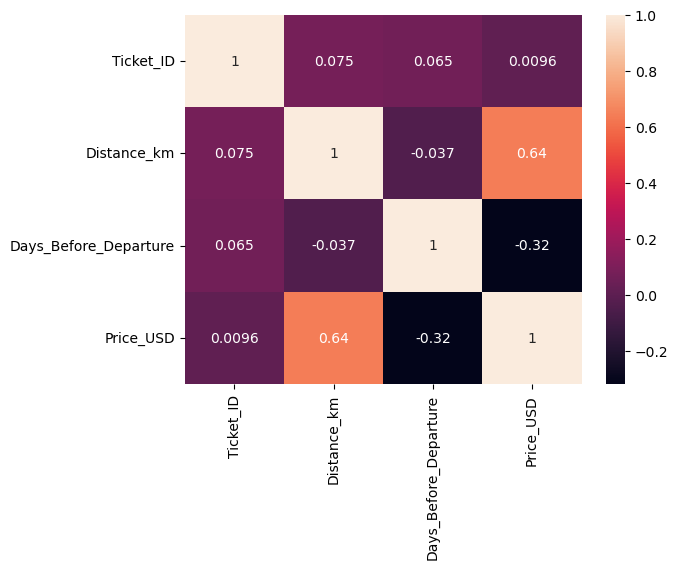

In [42]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Range: 40
Variance: 250.0
Standard deviation: 15.811388300841896


In [58]:
data = {
    "id": [1, 2, 3, 4, 5],
    "age": [25, 40, 35, 23, 60],
    "gender": ["Male", "Female", "Male", "Female", "Male"],
    "income": [50000, 80000, 60000, 40000, 90000],
    "purchase_made": [1, 0, 1, 0, 1]
}


df2= pd.DataFrame(data)
df2

,id,age,gender,income,purchase_made
0,1,25,Male,50000,1
1,2,40,Female,80000,0
2,3,35,Male,60000,1
3,4,23,Female,40000,0
4,5,60,Male,90000,1


In [59]:
df2.shape

(5, 5)

In [61]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             5 non-null      int64 
 1   age            5 non-null      int64 
 2   gender         5 non-null      object
 3   income         5 non-null      int64 
 4   purchase_made  5 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 332.0+ bytes


In [62]:
df2.describe()

,id,age,income,purchase_made
count,5.000000,5.000000,5.000000,5.000000
mean,3.000000,36.600000,64000.000000,0.600000
std,1.581139,14.842507,20736.441353,0.547723
min,1.000000,23.000000,40000.000000,0.000000
25%,2.000000,25.000000,50000.000000,0.000000
50%,3.000000,35.000000,60000.000000,1.000000
75%,4.000000,40.000000,80000.000000,1.000000
max,5.000000,60.000000,90000.000000,1.000000


<Axes: xlabel='count', ylabel='gender'>

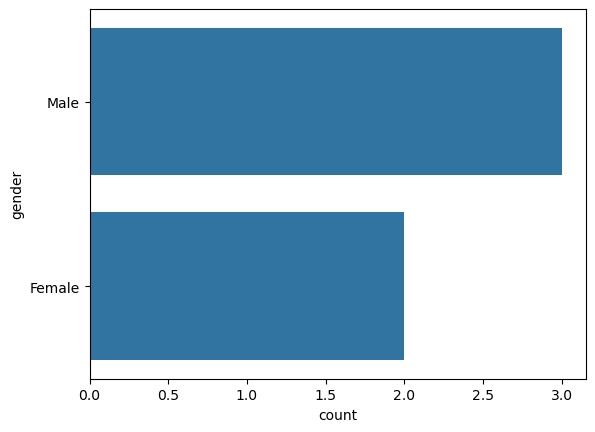

In [65]:
sns.countplot(df2['gender'])

<Axes: xlabel='age', ylabel='income'>

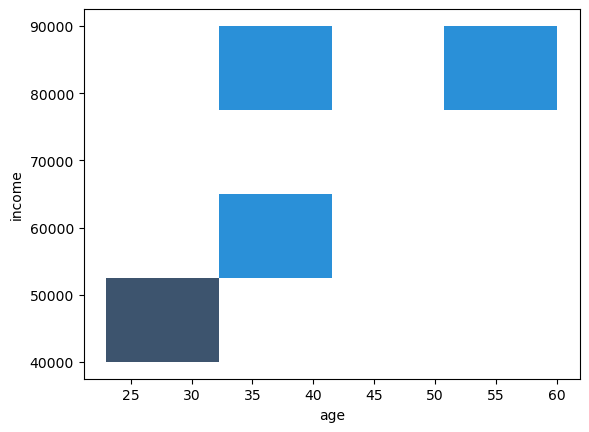

In [71]:
sns.histplot(x=df2['age'],y=df2['income'])

In [72]:
df2 = pd.get_dummies(df2, columns=['gender'])

In [73]:
df2

,id,age,income,purchase_made,gender_Female,gender_Male
0,1,25,50000,1,False,True
1,2,40,80000,0,True,False
2,3,35,60000,1,False,True
3,4,23,40000,0,True,False
4,5,60,90000,1,False,True


In [76]:
df2['age_group'] = pd.cut(
    df2['age'],
    bins=[0, 30, 50, 100],          # correct bin edges
    labels=['Child', 'Young', 'Adult']  # one label less than number of bins
)


In [77]:
df2

,id,age,income,purchase_made,gender_Female,gender_Male,age_group
0,1,25,50000,1,False,True,Child
1,2,40,80000,0,True,False,Young
2,3,35,60000,1,False,True,Young
3,4,23,40000,0,True,False,Child
4,5,60,90000,1,False,True,Adult


<Axes: ylabel='count'>

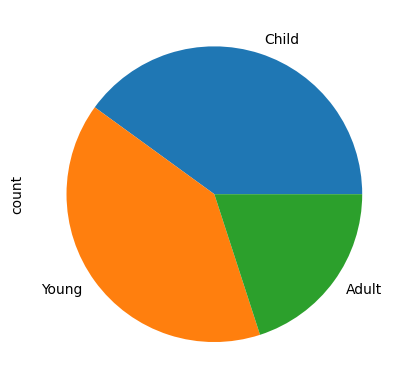

In [79]:
df2['age_group'].value_counts().plot(kind='pie')

In [81]:
df2['income_log'] = np.log1p(df2['income'])  # log(1 + income) to avoid log(0)
print(df2[['income', 'income_log']])

   income  income_log
0   50000   10.819798
1   80000   11.289794
2   60000   11.002117
3   40000   10.596660
4   90000   11.407576


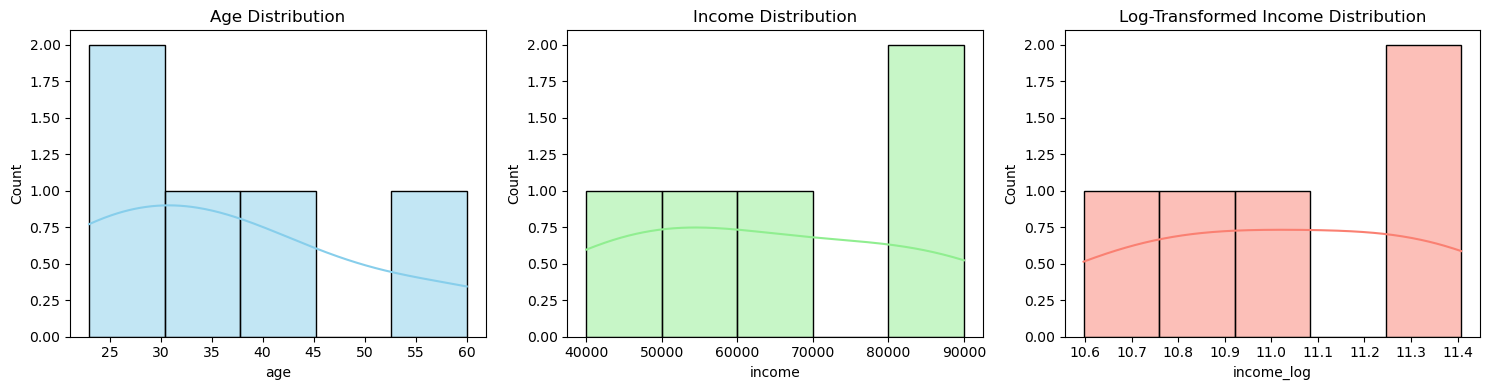

In [86]:
# Plot histograms
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df2['age'], kde=True, bins=5, color='skyblue')
plt.title('Age Distribution')

plt.subplot(1,3,2)
sns.histplot(df2['income'], kde=True, bins=5, color='lightgreen')
plt.title('Income Distribution')

plt.subplot(1,3,3)
sns.histplot(df2['income_log'], kde=True, bins=5, color='salmon')
plt.title('Log-Transformed Income Distribution')

plt.tight_layout()
plt.show()